In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
plt.rcParams['font.family']='meiryo'

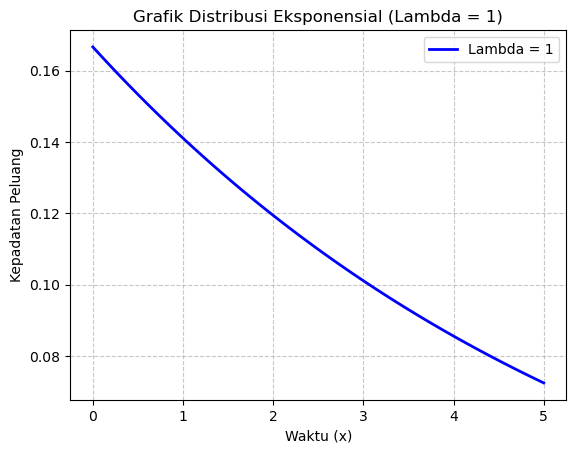

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import expon

# Menyiapkan data x dari 0 sampai 5
x = np.linspace(0, 5, 100)

# lambda = 1
# Catatan: Di scipy, scale = 1/lambda. Jadi jika lambda=1, scale=1.
plt.plot(x, expon.pdf(x, scale=6), label='Lambda = 1', color='blue', lw=2)

plt.title("Grafik Distribusi Eksponensial (Lambda = 1)")
plt.xlabel("Waktu (x)")
plt.ylabel("Kepadatan Peluang")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

In [25]:
inte = pd.read_csv('TGM 2020-2023_eng.csv', sep=';', decimal=',', encoding='utf-8')
inte

,Provinsi,Year,Reading Frequency per week,Number of Readings per Quarter,Daily Reading Duration (in minutes),Internet Access Frequency per Week,Daily Internet Duration (in minutes),Tingkat Kegemaran Membaca (Reading Interest),Category
0,Aceh,2020,4.0,2.0,95.0,NaN,NaN,54.68,Moderate
1,Aceh,2021,5.5,4.5,103.0,5.0,83.9,64.13,High
2,Aceh,2022,5.0,5.5,94.3,5.5,123.4,65.85,High
3,Aceh,2023,5.0,5.5,95.0,5.5,104.0,66.64,Moderate
4,Bali,2020,4.0,2.5,91.0,NaN,NaN,56.98,Moderate
...,...,...,...,...,...,...,...,...,...
135,West Sumatra,2023,5.5,5.5,104.0,6.0,128.0,68.46,Moderate
136,Yogyakarta,2020,5.0,2.5,123.0,NaN,NaN,65.73,High
137,Yogyakarta,2021,6.0,5.5,106.6,7.0,116.1,70.55,High
138,Yogyakarta,2022,5.5,7.0,111.1,7.0,125.9,72.29,High


In [22]:
import requests

# Link GeoJSON yang kita gunakan
geojson_url = "https://raw.githubusercontent.com/superpikar/indonesia-geojson/master/indonesia-province.json"
response = requests.get(geojson_url).json()

# Ambil semua nama provinsi dari GeoJSON
names_in_geojson = [feature['properties']['Propinsi'] for feature in response['features']]
print(names_in_geojson)

['IRIAN JAYA TIMUR', 'NUSATENGGARA BARAT', 'GORONTALO', 'SULAWESI TENGGARA', 'DAERAH ISTIMEWA YOGYAKARTA', 'JAWA TENGAH', 'PROBANTEN', 'JAWA TIMUR', 'MALUKU UTARA', 'MALUKU', 'KALIMANTAN SELATAN', 'KALIMANTAN BARAT', 'SULAWESI SELATAN', 'DKI JAKARTA', 'JAWA BARAT', 'IRIAN JAYA TENGAH', 'NUSA TENGGARA TIMUR', 'BALI', 'RIAU', 'SULAWESI TENGAH', 'KALIMANTAN TIMUR', 'SULAWESI UTARA', 'IRIAN JAYA BARAT', 'SUMATERA UTARA', 'BANGKA BELITUNG', 'SUMATERA BARAT', 'KALIMANTAN TENGAH', 'SUMATERA SELATAN', 'JAMBI', 'LAMPUNG', 'BENGKULU', 'DI. ACEH']


In [ ]:
# 1. Hapus baris 'Indonesia' karena bukan provinsi
df = inte[inte['Provinsi'] != 'Indonesia']

# 2. Kamus sinkronisasi (Mapping)
# Menyesuaikan nama CSV agar SAMA PERSIS dengan list GeoJSON yang kamu dapatkan
mapping_fix = {
    'Aceh': 'DI. ACEH',
    'Jakarta': 'DKI JAKARTA',
    'Yogyakarta': 'DAERAH ISTIMEWA YOGYAKARTA',
    'Banten': 'PROBANTEN',
    'Bangka Belitung Islands': 'BANGKA BELITUNG',
    'West Nusa Tenggara': 'NUSATENGGARA BARAT',
    'West Papua': 'IRIAN JAYA BARAT',
    'Papua': 'IRIAN JAYA TIMUR',
    'East Kalimantan': 'KALIMANTAN TIMUR',
    'West Kalimantan': 'KALIMANTAN BARAT',
    'Central Kalimantan': 'KALIMANTAN TENGAH',
    'South Kalimantan': 'KALIMANTAN SELATAN',
    'East Java': 'JAWA TIMUR',
    'West Java': 'JAWA BARAT',
    'Central Java': 'JAWA TENGAH',
    'North Sumatra': 'SUMATERA UTARA',
    'West Sumatra': 'SUMATERA BARAT',
    'South Sumatra': 'SUMATERA SELATAN',
    'North Sulawesi': 'SULAWESI UTARA',
    'Central Sulawesi': 'SULAWESI TENGAH',
    'South Sulawesi': 'SULAWESI SELATAN',
    'South East Sulawesi': 'SULAWESI TENGGARA'
}

# Terapkan perubahan
df['Provinsi_Peta'] = df['Provinsi'].replace(mapping_fix)
fig_map = px.choropleth(
    df_filtered,
    geojson=geojson_url,
    locations='Provinsi_Peta',      # <--- Gunakan kolom hasil mapping
    featureidkey="properties.Propinsi", 
    color='Tingkat Kegemaran Membaca (Reading Interest)',
    # ... parameter lainnya
)

C:\Users\adist\AppData\Local\Temp\ipykernel_12088\70090814.py:32: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [18]:
inte['Provinsi'].unique()

array(['Aceh', 'Bali', 'Bangka Belitung Islands', 'Banten', 'Bengkulu',
       'Central Java', 'Central Kalimantan', 'Central Sulawesi',
       'East Java', 'East Kalimantan', 'East Nusa Tenggara', 'Gorontalo',
       'Indonesia', 'Jakarta', 'Jambi', 'Lampung', 'Maluku',
       'North Kalimantan', 'North Maluku', 'North Sulawesi',
       'North Sumatra', 'Papua', 'Riau', 'Riau Islands',
       'South East Sulawesi', 'South Kalimantan', 'South Sulawesi',
       'South Sumatra', 'West Java', 'West Kalimantan',
       'West Nusa Tenggara', 'West Papua', 'West Sulawesi',
       'West Sumatra', 'Yogyakarta'], dtype=object)

In [4]:
inter = inte.fillna('-').isnull().sum()


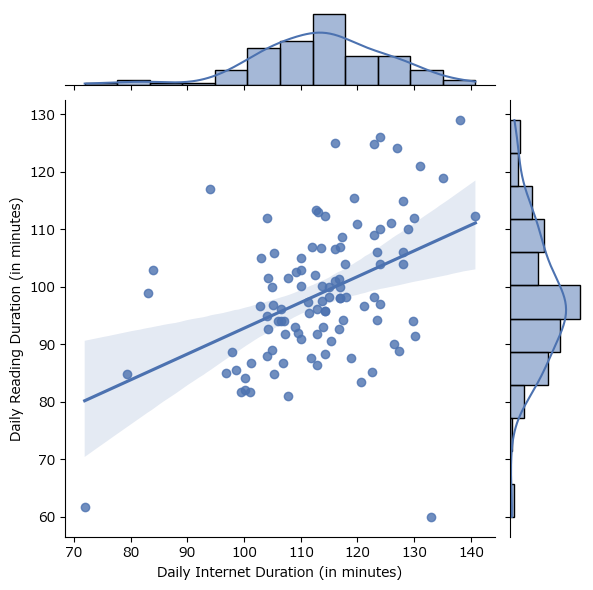

In [9]:
# Sumbu X: Durasi Internet, Sumbu Y: Durasi Membaca
sns.jointplot(data=inte, 
              x="Daily Internet Duration (in minutes)", 
              y="Daily Reading Duration (in minutes)", 
              kind="reg", # Menambahkan garis tren (regresi)
              color="#4C72B0")
plt.show()

In [19]:
mapping = {
    "Aceh": "Aceh",
    "Bali": "Bali",
    "Bangka Belitung Islands": "Kepulauan Bangka Belitung",
    "Banten": "Banten",
    "Bengkulu": "Bengkulu",
    "Central Java": "Jawa Tengah",
    "Central Kalimantan": "Kalimantan Tengah",
    "Central Sulawesi": "Sulawesi Tengah",
    "East Java": "Jawa Timur",
    "East Kalimantan": "Kalimantan Timur",
    "East Nusa Tenggara": "Nusa Tenggara Timur",
    "Gorontalo": "Gorontalo",
    "Indonesia": "Indonesia",  # kalau ini agregat nasional, nanti bisa di-drop
    "Jakarta": "DKI Jakarta",
    "Jambi": "Jambi",
    "Lampung": "Lampung",
    "Maluku": "Maluku",
    "North Kalimantan": "Kalimantan Utara",
    "North Maluku": "Maluku Utara",
    "North Sulawesi": "Sulawesi Utara",
    "North Sumatra": "Sumatera Utara",
    "Papua": "Papua",
    "Riau": "Riau",
    "Riau Islands": "Kepulauan Riau",
    "South East Sulawesi": "Sulawesi Tenggara",
    "South Kalimantan": "Kalimantan Selatan",
    "South Sulawesi": "Sulawesi Selatan",
    "South Sumatra": "Sumatera Selatan",
    "West Java": "Jawa Barat",
    "West Kalimantan": "Kalimantan Barat",
    "West Nusa Tenggara": "Nusa Tenggara Barat",
    "West Papua": "Papua Barat",
    "West Sulawesi": "Sulawesi Barat",
    "West Sumatra": "Sumatera Barat",
    "Yogyakarta": "DI Yogyakarta",
}


In [ ]:
df_filtered["Provinsi_geo"] = df_filtered["Provinsi"].replace(mapping)

# Kalau baris "Indonesia" tidak perlu dipetakan di peta:
df_filtered = df_filtered[df_filtered["Provinsi_geo"] != "Indonesia"]

fig_map = px.choropleth(
    df_filtered,
    geojson=geojson_url,  # atau geojson_data kalau kamu load dulu
    locations="Provinsi_geo",
    featureidkey="properties.NAME_1",
    color="Tingkat Kegemaran Membaca (Reading Interest)",
    color_continuous_scale="Viridis",
    template="plotly_dark"
)


In [21]:
import streamlit as st
import pandas as pd
import plotly.express as px
import requests

# --- Filter data per tahun ---
df_year = inte[inte["Year"] == selected_year].copy()

# --- Mapping nama provinsi EN -> ID ---
mapping = {
    "Aceh": "Aceh",
    "Bali": "Bali",
    "Bangka Belitung Islands": "Kepulauan Bangka Belitung",
    "Banten": "Banten",
    "Bengkulu": "Bengkulu",
    "Central Java": "Jawa Tengah",
    "Central Kalimantan": "Kalimantan Tengah",
    "Central Sulawesi": "Sulawesi Tengah",
    "East Java": "Jawa Timur",
    "East Kalimantan": "Kalimantan Timur",
    "East Nusa Tenggara": "Nusa Tenggara Timur",
    "Gorontalo": "Gorontalo",
    "Indonesia": None,  # baris agregat, nanti dibuang
    "Jakarta": "DKI Jakarta",
    "Jambi": "Jambi",
    "Lampung": "Lampung",
    "Maluku": "Maluku",
    "North Kalimantan": "Kalimantan Utara",
    "North Maluku": "Maluku Utara",
    "North Sulawesi": "Sulawesi Utara",
    "North Sumatra": "Sumatera Utara",
    "Papua": "Papua",
    "Riau": "Riau",
    "Riau Islands": "Kepulauan Riau",
    "South East Sulawesi": "Sulawesi Tenggara",
    "South Kalimantan": "Kalimantan Selatan",
    "South Sulawesi": "Sulawesi Selatan",
    "South Sumatra": "Sumatera Selatan",
    "West Java": "Jawa Barat",
    "West Kalimantan": "Kalimantan Barat",
    "West Nusa Tenggara": "Nusa Tenggara Barat",
    "West Papua": "Papua Barat",
    "West Sulawesi": "Sulawesi Barat",
    "West Sumatra": "Sumatera Barat",
    "Yogyakarta": "DI Yogyakarta",
}

df_year["Provinsi_geo"] = df_year["Provinsi"].replace(mapping)
df_year = df_year[df_year["Provinsi_geo"].notna()]  # buang "Indonesia" / None

# --- Load GeoJSON provinsi Indonesia ---
geojson_url = "https://raw.githubusercontent.com/superpikar/indonesia-geojson/master/indonesia-province.json"
geojson_data = requests.get(geojson_url).json()

# --- Plot choropleth ---
st.subheader(f"🗺️ Peta Tingkat Kegemaran Membaca ({selected_year})")

fig_map = px.choropleth(
    df_year,
    geojson=geojson_data,
    locations="Provinsi_geo",
    featureidkey="properties.NAME_1",
    color="Tingkat Kegemaran Membaca (Reading Interest)",
    color_continuous_scale="Viridis",
    template="plotly_dark"
)

fig_map.update_geos(fitbounds="locations", visible=False)
fig_map.update_layout(
    height=500,
    margin={"r":0,"t":0,"l":0,"b":0},
    paper_bgcolor="rgba(0,0,0,0)"
)

st.plotly_chart(fig_map, use_container_width=True)
st.caption("Semakin terang warna, semakin tinggi tingkat kegemaran membaca di provinsi tersebut.")


NameError: name 'selected_year' is not defined

1. Tahap Pembukaan: Kondisi Saat Ini (Snapshots)
Tujuannya adalah memberi tahu pembaca "Di mana posisi kita sekarang?".

KPI Cards (Metrik Utama): Menampilkan angka rata-rata TKM nasional, durasi baca, dan durasi internet untuk tahun terbaru.

Peta Indonesia (Choropleth Map): Memberikan konteks geografis. Wilayah mana yang sudah "Hijau" (Tinggi) dan mana yang masih "Merah" (Rendah).

Pie Chart (Nasional): Menunjukkan proporsi kategori (misal: berapa persen provinsi yang sudah masuk kategori 'Moderat' atau 'Tinggi').

2. Tahap Perkembangan: Tren Waktu (Historical Trends)
Tujuannya adalah menjawab pertanyaan "Apakah kita menjadi lebih baik dari tahun ke tahun?".

Combo Bar & Line Chart: Batang (Bar) menunjukkan Jumlah Bacaan per Kuartal, dan garis (Line) menunjukkan Skor TKM. Ini sangat efektif untuk melihat apakah peningkatan jumlah buku yang dibaca sebanding dengan kenaikan minat baca.

Joyplot / Ridgeline Plot: Menampilkan distribusi durasi membaca dari tahun 2020 hingga 2023. Ini menunjukkan apakah puncak kebiasaan masyarakat bergeser ke arah durasi yang lebih lama.

3. Tahap Pendalaman: Hierarki & Detail (Structure)
Tujuannya adalah membedah data per wilayah tanpa membuat audiens pusing.

Treemap: Ini adalah solusi terbaik untuk menampilkan 38 provinsi sekaligus. Provinsi dikelompokkan berdasarkan kategori (Tinggi, Sedang, Rendah). Ukuran kotak mewakili skor TKM.

4. Tahap Analisis Penyebab: Korelasi (Relationship)
Tujuannya adalah mencari hubungan antar variabel (Faktor Pendukung/Penghambat).

Scatter Plot dengan Marginal Histogram (Joint Plot): Membenturkan Internet Duration dengan Daily Reading Duration.

Insight: Apakah akses internet yang tinggi justru menurunkan minat baca, atau malah mendukungnya karena masyarakat membaca lewat platform digital?

Urutan Penyajian dalam Laporan/Dashboard
Agar audiens mudah memahami, susunlah visualisasi tersebut dengan urutan berikut:

Overview: KPI Cards & Peta (Apa yang terjadi?).

Growth: Tren Tahunan (Bagaimana perubahannya?).

Breakdown: Treemap (Wilayah mana yang menonjol?).

Correlation: Scatter Plot (Mengapa hal itu terjadi?).

Tips Final untuk UI Dashboard Anda
Latar Belakang Hitam: Gunakan warna abu-abu gelap atau hitam untuk kesan profesional dan membuat warna grafik (Cyan, Emerald, Orange) terlihat kontras dan menyala.

Interaktivitas: Pastikan ada filter tahun (Slider) yang mengubah seluruh grafik secara bersamaan agar audiens bisa melakukan eksplorasi mandiri.

Apakah Anda ingin saya membantu membuatkan draf "Narasi Penutup" atau kesimpulan otomatis berdasarkan skor tertinggi dan terendah dari data Anda?